In [2]:
!pip3 install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [1]:
import sys
!{sys.executable} -m pip install seaborn scikit-learn matplotlib pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("SpotifySongs2019.csv")
print(df.head())

                      id                                           name  \
0  6v3KW9xbzN5yKLt9YKDYA                                       Señorita   
1  2Fxmhks0bxGSBdJ92vM42                                        bad guy   
2  0RiRZpuVRbi7oqRdSMwhQ  Sunflower - Spider-Man: Into the Spider-Verse   
3  6ocbgoVGwYJhOv1GgI9Ns                                        7 rings   
4  2YpeDb67231RjR0MgVLzs                          Old Town Road - Remix   

         artists  danceability  energy  key  loudness  mode  speechiness  \
0   Shawn Mendes         0.759   0.548  9.0    -6.049   0.0       0.0290   
1  Billie Eilish         0.701   0.425  7.0   -10.965   1.0       0.3750   
2    Post Malone         0.755   0.522  2.0    -4.368   1.0       0.0575   
3  Ariana Grande         0.778   0.317  1.0   -10.732   0.0       0.3340   
4      Lil Nas X         0.878   0.619  6.0    -5.560   1.0       0.1020   

   acousticness  instrumentalness  liveness  valence    tempo  duration_ms  \
0        0.039

## #1 ##

Machine learning is when a computer learns patterns from data so it can make predictions on new data. The goal of it is to use song features to predict another variable. In this dataset, the target variable is danceability because it is numeric and the worksheet asks to predict it. Using other features like energy, tempo, loudness, and valence, the program can try to predict how danceable a song is.

## #2 ##

In [6]:
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

                      id                                           name  \
0  6v3KW9xbzN5yKLt9YKDYA                                       Señorita   
1  2Fxmhks0bxGSBdJ92vM42                                        bad guy   
2  0RiRZpuVRbi7oqRdSMwhQ  Sunflower - Spider-Man: Into the Spider-Verse   
3  6ocbgoVGwYJhOv1GgI9Ns                                        7 rings   
4  2YpeDb67231RjR0MgVLzs                          Old Town Road - Remix   

         artists  danceability  energy  key  loudness  mode  speechiness  \
0   Shawn Mendes         0.759   0.548  9.0    -6.049   0.0       0.0290   
1  Billie Eilish         0.701   0.425  7.0   -10.965   1.0       0.3750   
2    Post Malone         0.755   0.522  2.0    -4.368   1.0       0.0575   
3  Ariana Grande         0.778   0.317  1.0   -10.732   0.0       0.3340   
4      Lil Nas X         0.878   0.619  6.0    -5.560   1.0       0.1020   

   acousticness  instrumentalness  liveness  valence    tempo  duration_ms  \
0        0.039

## #3 ##

In [42]:
features = ['name', 'artists', 'energy']
X = df[features]
y = df['danceability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (40, 3)
Testing set size: (10, 3)


## #4 ##

In [13]:
X = df[['energy', 'loudness', 'tempo']]
y = df['danceability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X_train, y_train)

print('Coefficients:', model1.coef_)
print('Intercept:', model1.intercept_)

Coefficients: [0.27411498 0.00734545 0.00039723]
Intercept: 0.5536165769256871


In [18]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred1 = model1.predict(X_test)

mse1 = mean_squared_error(y_test, y_pred1)
r2_1 = r2_score(y_test, y_pred1)

print('Model 1 MSE:', mse1)
print('Model 1 R^2:', r2_1)

Model 1 MSE: 0.027144212830012348
Model 1 R^2: -1.0720520077626796


## #5 ##

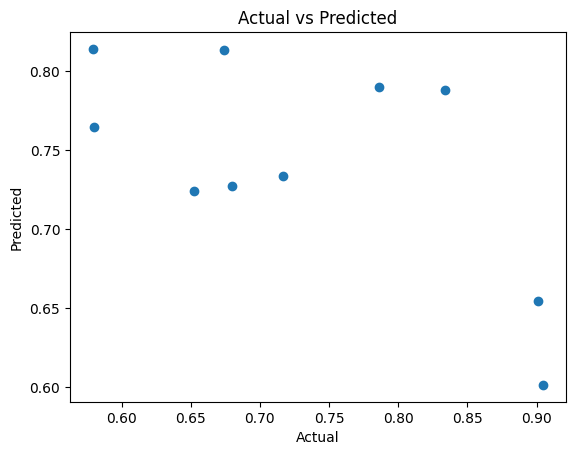

In [14]:
y_pred1 = model1.predict(X_test)

plt.scatter(y_test, y_pred1)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

## #6 ##

In [20]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.8, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

mse2 = mean_squared_error(y_test2, y_pred2)
r2_2 = r2_score(y_test2, y_pred2)

print('Model 2 MSE:', mse2)
print('Model 2 R^2:', r2_2)

Model 2 MSE: 0.020495070638120873
Model 2 R^2: -0.47776290490779916


With a smaller training set, the model performed worse because it had less data to learn from. If the R^2 score goes down or the MSE goes up, that means the model became less accurate.

## #7 ##

In [23]:
all_numeric = df.select_dtypes(include='number').columns.tolist()
all_features = [col for col in all_numeric if col != 'danceability']

X_all = df[all_features]
y = df['danceability']

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

model3 = LinearRegression()
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)

mse3 = mean_squared_error(y_test3, y_pred3)
r2_3 = r2_score(y_test3, y_pred3)

print('Model 3 MSE:', mse3)
print('Model 3 R^2:', r2_3)
print('Features used:', all_features)

Model 3 MSE: 0.04143531297111032
Model 3 R^2: -2.1629623585597666
Features used: ['energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature']


Using more features can improve the model if the features are related to danceability. If model3 has a higher R^2 and lower MSE than model1, then the extra features helped. But if not, then some added features might not be useful.

## #8 ##

danceability        1.000000
valence             0.391774
energy              0.273068
speechiness         0.227283
loudness            0.178688
key                 0.165208
instrumentalness    0.153419
tempo               0.149066
mode                0.007662
liveness           -0.088595
duration_ms        -0.132798
acousticness       -0.465118
time_signature           NaN
Name: danceability, dtype: float64


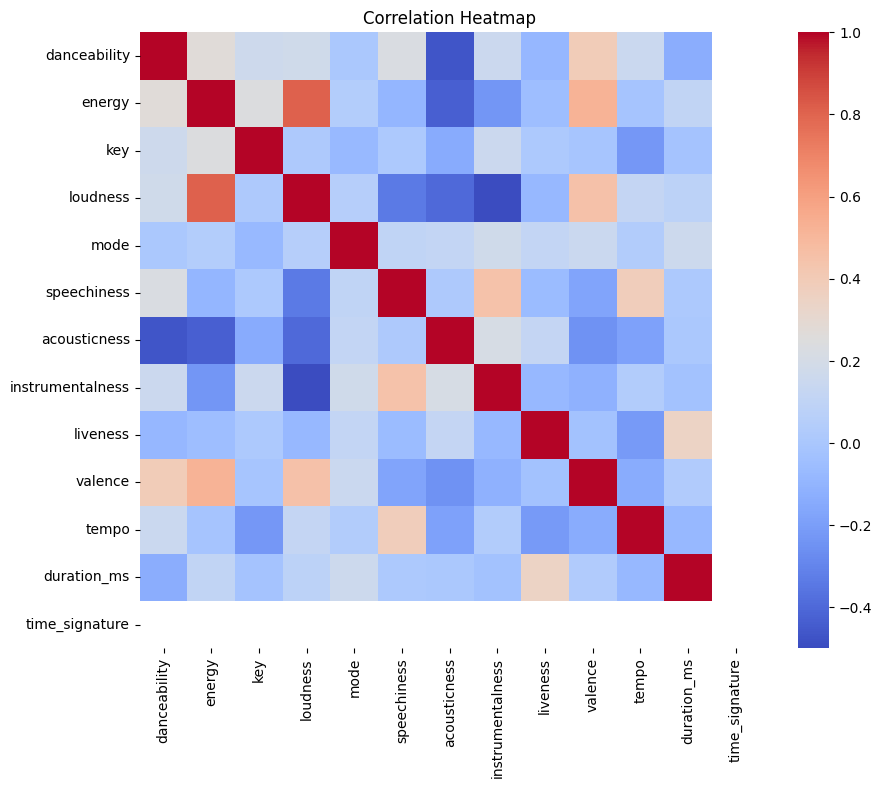

In [36]:
numeric_df = df.select_dtypes(include="number")

corr_matrix = numeric_df.corr()
print(corr_matrix["danceability"].sort_values(ascending=False))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

The correlation matrix shows which features the most related to danceability. Features with greater positive values are positively related, while features with more negative values are negatively related. The features with the strongest correlations are the best ones to consider for the model because they can predict danceability more effectively.

## #9 ##

I think a good model makes accurate predictions on an unseen data, not just with the training data. It should have a balance between bias and variance, meaning it captures patterns without overfitting. To improve this model, I would try to add more relevant features, tuning the model parameters or testing different types of models to see which performs best.

## #10 ##

In [40]:
from sklearn.metrics import mean_squared_error, r2_score

# Model 1
print("Model 1 MSE:", mse1)
print("Model 1 R^2:", r2_1)

# Model 2
print("Model 2 MSE:", mse2)
print("Model 2 R^2:", r2_2)

# Model 3
print("Model 3 MSE:", mse3)
print("Model 3 R^2:", r2_3)

Model 1 MSE: 0.027144212830012348
Model 1 R^2: -1.0720520077626796
Model 2 MSE: 0.020495070638120873
Model 2 R^2: -0.47776290490779916
Model 3 MSE: 0.04143531297111032
Model 3 R^2: -2.1629623585597666


In [41]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3"],
    "MSE": [mse1, mse2, mse3],
    "R^2": [r2_1, r2_2, r2_3]
})

print(results)

     Model       MSE       R^2
0  Model 1  0.027144 -1.072052
1  Model 2  0.020495 -0.477763
2  Model 3  0.041435 -2.162962


R^2 measures how much percent of variation in the target variable (y) can be explained in the model (x), while MSE measures the average squared difference between predicted and actual values. A good model would have a higher R^2 and lower MSE. Typically, the model with more features (model3) performs better because it uses more information, while the model with less training data (model2) was worse due to insufficient learning.